In [1]:
import pandas as pd
import numpy as np
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
df = pd.read_csv("/content/IMDB Dataset.csv", on_bad_lines='skip', engine='python')

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
print("Shape:", df.shape)
print(df['sentiment'].value_counts())

Shape: (1613, 2)
sentiment
positive    820
negative    793
Name: count, dtype: int64


In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r"http\S+", "", text)

    # 3. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 4. Remove special characters
    text = re.sub(r"[^a-zA-Z]", " ", text)

    # 5. Tokenization
    tokens = text.split()

    # 6. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # 7. Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return tokens

In [7]:
df['tokens'] = df['review'].apply(preprocess_text)

In [8]:
def tokens_to_sentence(tokens):
    return " ".join(tokens)

df['clean_text'] = df['tokens'].apply(tokens_to_sentence)

df.head()

,review,sentiment,tokens,clean_text
0,One of the other reviewers has mentioned that ...,positive,"[one, reviewer, mentioned, watching, oz, episo...",one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,positive,"[wonderful, little, production, br, br, filmin...",wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,"[basically, there, family, little, boy, jake, ...",basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"[petter, matteis, love, time, money, visually,...",petter matteis love time money visually stunni...


In [9]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_text'])

In [10]:
y = df['sentiment']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [13]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

In [14]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [15]:
def evaluate(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, pos_label='positive'))
    print("Recall:", recall_score(y_test, y_pred, pos_label='positive'))
    print("F1 Score:", f1_score(y_test, y_pred, pos_label='positive'))

In [16]:
print("Logistic Regression")
evaluate(y_test, y_pred_lr)

print("\nNaive Bayes")
evaluate(y_test, y_pred_nb)

print("\nDecision Tree")
evaluate(y_test, y_pred_dt)

Logistic Regression
Accuracy: 0.8204334365325078
Precision: 0.8181818181818182
Recall: 0.8470588235294118
F1 Score: 0.8323699421965318

Naive Bayes
Accuracy: 0.8359133126934984
Precision: 0.8726114649681529
Recall: 0.8058823529411765
F1 Score: 0.8379204892966361

Decision Tree
Accuracy: 0.718266253869969
Precision: 0.7309941520467836
Recall: 0.7352941176470589
F1 Score: 0.7331378299120235


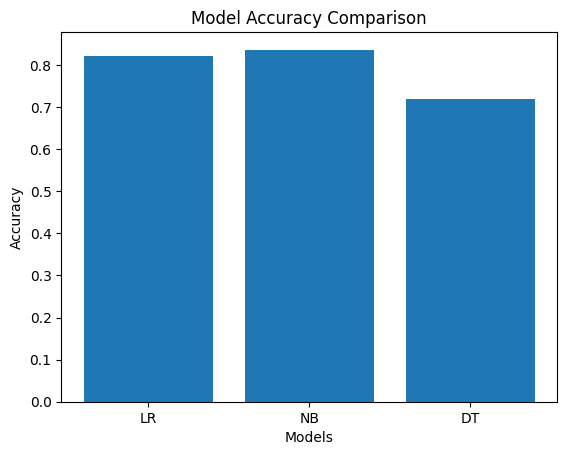

In [17]:
import matplotlib.pyplot as plt

models = ['LR', 'NB', 'DT']
accuracy = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_dt)
]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()